In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import style
style.use('seaborn-v0_8')
from matplotlib.pyplot import rcParams
rcParams['figure.figsize']=10,5
import warnings
warnings.filterwarnings('ignore')

print('modules imported!')

modules imported!


In [2]:
df = pd.read_csv('Supermart Grocery Sales.csv')
print('Done!')


Done!


In [3]:
df.head()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


In [4]:
#check the size of the dataset
df.shape

(9994, 11)

In [5]:
#Get information about the datatypes ,shape and names of the columns in the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   str    
 1   Customer Name  9994 non-null   str    
 2   Category       9994 non-null   str    
 3   Sub Category   9994 non-null   str    
 4   City           9994 non-null   str    
 5   Order Date     9994 non-null   str    
 6   Region         9994 non-null   str    
 7   Sales          9994 non-null   int64  
 8   Discount       9994 non-null   float64
 9   Profit         9994 non-null   float64
 10  State          9994 non-null   str    
dtypes: float64(2), int64(1), str(8)
memory usage: 859.0 KB


In [6]:
#Get the descriptive statisticsof the data
df.describe()

,Sales,Discount,Profit
count,9994.000000,9994.000000,9994.000000
mean,1496.596158,0.226817,374.937082
std,577.559036,0.074636,239.932881
min,500.000000,0.100000,25.250000
25%,1000.000000,0.160000,180.022500
50%,1498.000000,0.230000,320.780000
75%,1994.750000,0.290000,525.627500
max,2500.000000,0.350000,1120.950000


In [7]:
#Check for any missing values
df.isnull().sum()

Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64

In [8]:
#check for duplicated data
df.duplicated().sum()

np.int64(0)

In [9]:
#change column names to lowercase to make it easier to work with
df.columns=df.columns.str.lower()

#remove the North region: it has only 1 order, so it can't be compared with other regions
df=df[df['region']!='North']

## Business problems to be solved using this dataset:

### 1.Sales Performance Analysis.Which categories has the most sales, & which ones are underperforming?

### 2.Regional Market Analysis.Which region are experiencing more sales and which ones are lagging?

### 3.Which 5 cities have the highest sales & profit?

### 4.Sales vs Profit Analysis.Do the sales significantly impact the profit?

### 5.Discount Rate Analysis.Does the discount have any effect on profit?

### 6.Sub Category Analysis.Which sub categories have the most sales & profit?

### 7.Yearly sales performance per region.

### 8.Yearly profit per category.Which category performed the best & which ones didn't?

## 1.Sales Performance Analysis

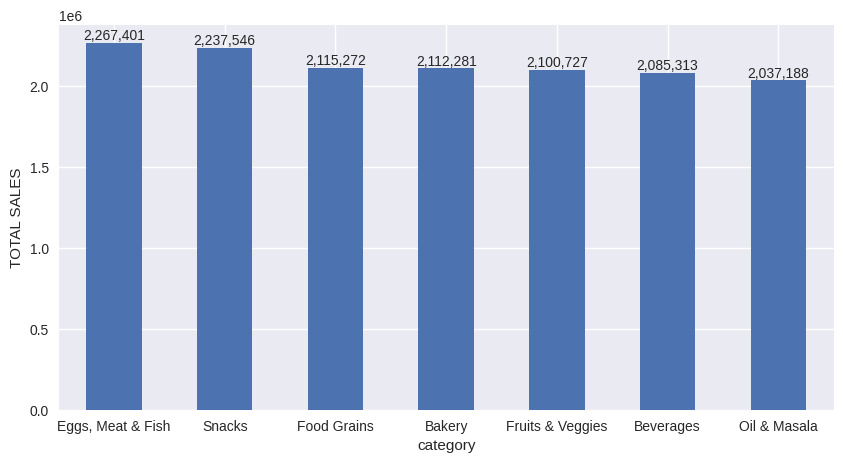

In [10]:
cat_sales=df.groupby('category')['sales'].sum()
sorted_cat_sales=cat_sales.sort_values(ascending=False)
sorted_cat_sales.plot(kind='bar')
plt.ylabel('TOTAL SALES')
plt.xticks(rotation=0,ha='center')
for i, v in enumerate(sorted_cat_sales):
    plt.text(i, v, f'{v:,.0f}', ha='center', va='bottom')

plt.show()

## 2.Regional Sales Analysis

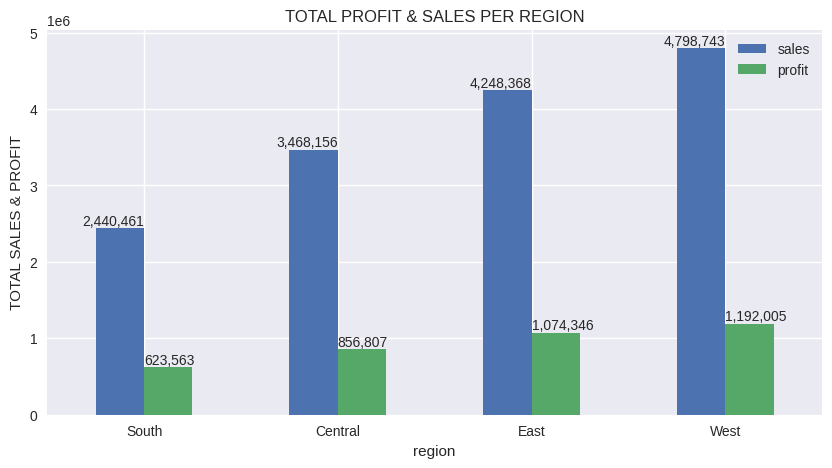

In [11]:
reg_sales=df.groupby('region').agg({'sales':'sum','profit':'sum'}).reset_index()
sorted_reg_sales=reg_sales.sort_values(by='sales',ascending=True)
sorted_reg_sales.set_index('region',inplace=True)
sorted_reg_sales.plot(kind='bar')
plt.title('TOTAL PROFIT & SALES PER REGION')
plt.ylabel('TOTAL SALES & PROFIT')
plt.xticks(rotation=0,ha='center')
for i, v in enumerate(sorted_reg_sales['sales']):
    plt.text(i, v, f'{v:,.0f}', ha='right', va='bottom')
    
for i, v in enumerate(sorted_reg_sales['profit']):
    plt.text(i, v, f'{v:,.0f}', ha='left', va='bottom')    

plt.show()

## 3.Top 5 cities exceling in sales & profit

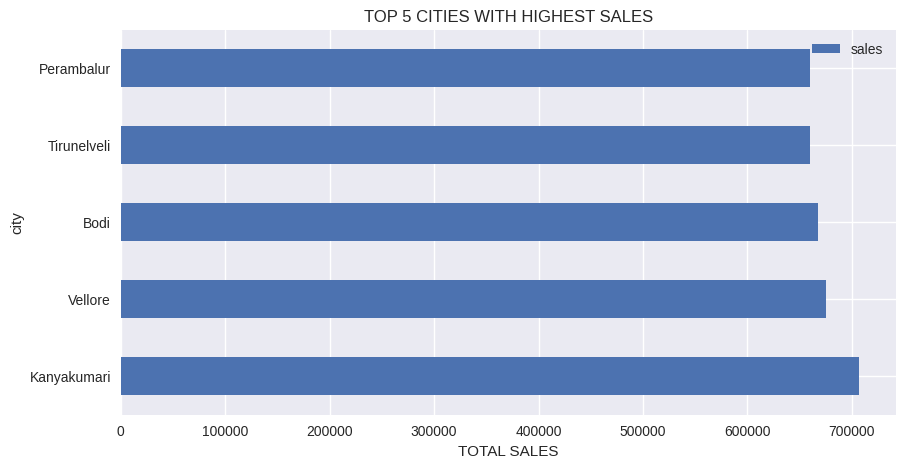

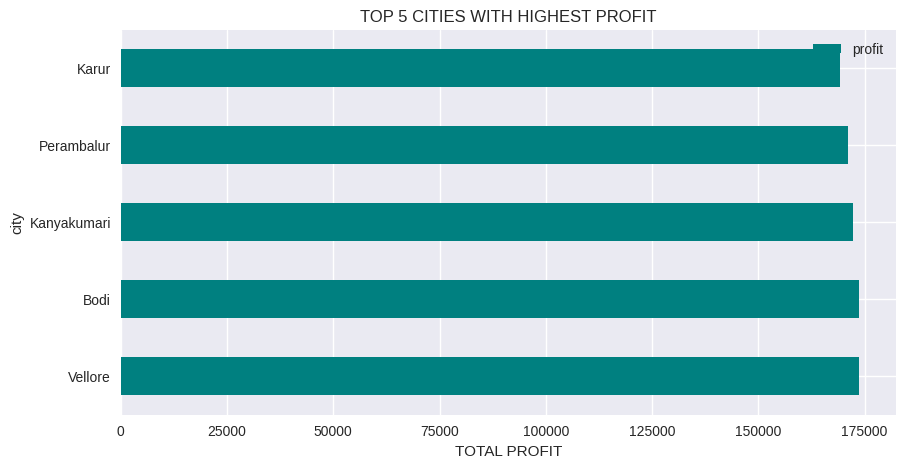

In [12]:
city_sales = df.groupby('city').agg({'sales':'sum'}).reset_index()

sorted_city_sales = city_sales.sort_values(by='sales',ascending=False)
sorted_city_sales.set_index('city',inplace=True)
sorted_city_sales.head(5).plot(kind ='barh')
plt.xlabel('TOTAL SALES')
plt.title('TOP 5 CITIES WITH HIGHEST SALES')

city_profit = df.groupby('city').agg({'profit':'sum'}).reset_index()
sorted_city_profit = city_profit.sort_values(by='profit',ascending=False)
sorted_city_profit.set_index('city',inplace=True)
sorted_city_profit.head(5).plot(kind ='barh',color='teal')
plt.xlabel('TOTAL PROFIT')
plt.title('TOP 5 CITIES WITH HIGHEST PROFIT')

plt.show()

## 4.Sales vs Profit Analysis

<Axes: >

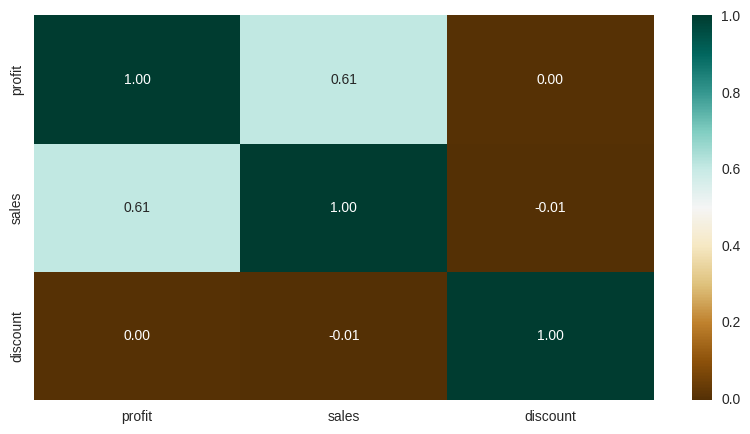

In [13]:
profit=df[['profit','sales','discount']].corr()
sns.heatmap(profit,cmap='BrBG',annot=True,fmt='.2f')

## 5.Discount Analysis

In [14]:
discount=df.groupby('region').agg({'sales':'sum','profit':'sum','discount':'mean'}).reset_index()
sorted_discount=discount.sort_values(by='discount',ascending=False)
sorted_discount.set_index('region',inplace=True)
sorted_discount

,sales,profit,discount
region,,,
Central,3468156,856806.84,0.228726
East,4248368,1074345.58,0.227672
South,2440461,623562.89,0.226776
West,4798743,1192004.61,0.224727


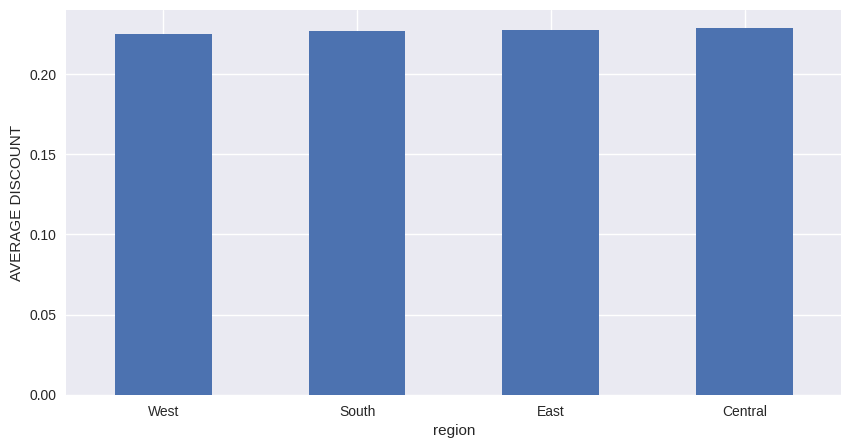

In [15]:
reg_dis=df.groupby('region')['discount'].mean().reset_index()
sort_reg_dis= reg_dis.sort_values(by='discount',ascending=True)
sort_reg_dis.set_index('region',inplace=True)
sort_reg_dis.plot(kind='bar',legend=False)
plt.ylabel('AVERAGE DISCOUNT')
plt.xticks(rotation=0)
plt.show()

## 6.Sales Performance Per Sub Category

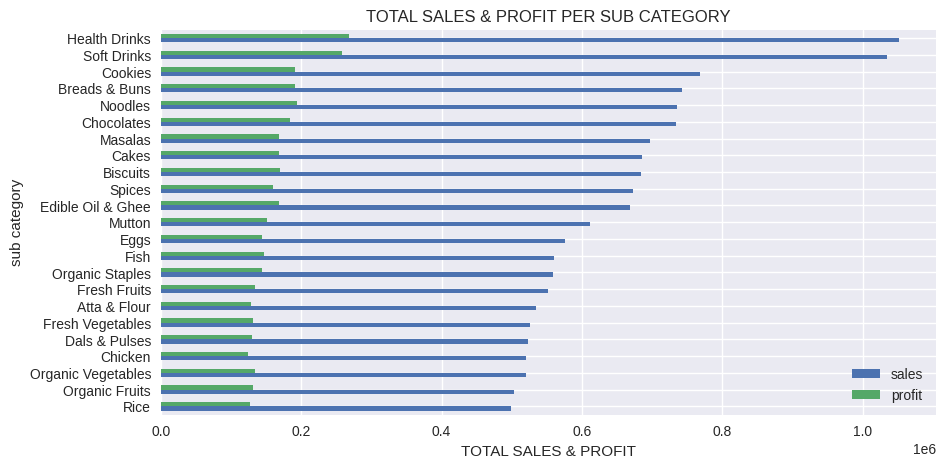

In [16]:
subcat_sales=df.groupby('sub category').agg({'sales':'sum','profit':'sum'}).reset_index()
sorted_subcat_sales=subcat_sales.sort_values(by=['sales','profit'])
sorted_subcat_sales.set_index('sub category',inplace=True)
sorted_subcat_sales.plot(kind='barh')
plt.xlabel('TOTAL SALES & PROFIT')
plt.title('TOTAL SALES & PROFIT PER SUB CATEGORY')
plt.show()

## 7.Yearly Sales Performance Per Region

In [17]:
df['year']=pd.to_datetime(df['order date'], format='mixed').dt.year


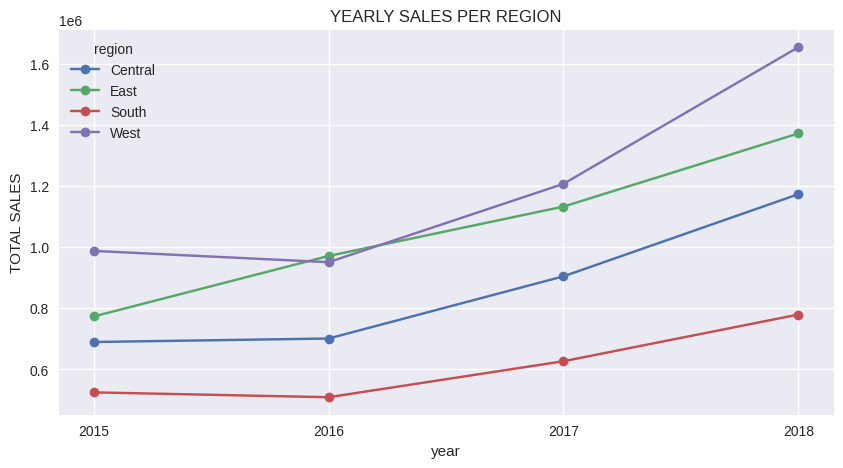

In [18]:
yearly_sales=df.groupby(['year','region'])['sales'].sum().unstack()
yearly_sales=yearly_sales.sort_index()
yearly_sales.plot(kind='line',marker='o')
plt.xticks(yearly_sales.index)
plt.ylabel('TOTAL SALES')
plt.title('YEARLY SALES PER REGION')
plt.show()

## 8.Yearly Profit Per Category

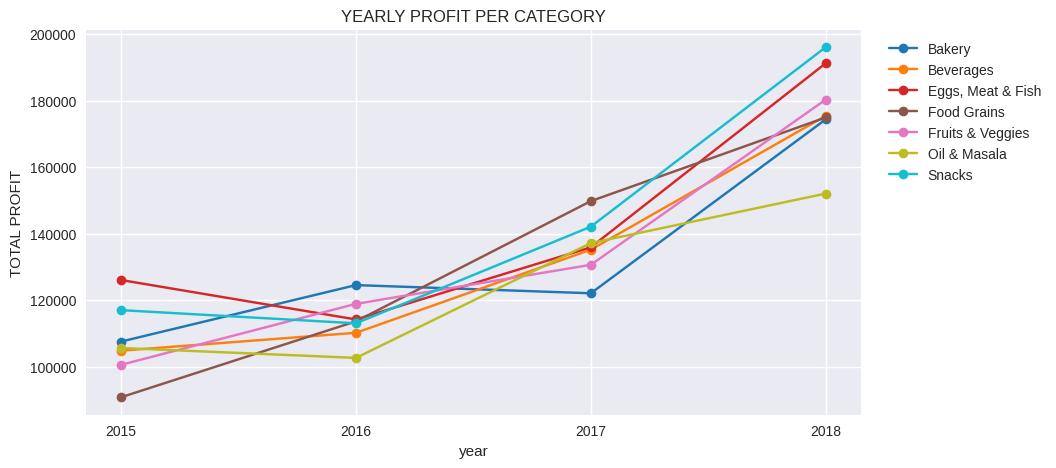

In [19]:
yearly_profit=df.groupby(['year','category'])['profit'].sum().unstack()
yearly_profit=yearly_profit.sort_index()
yearly_profit.plot(kind='line',marker='o',colormap='tab10')
plt.xticks(yearly_profit.index)
plt.ylabel('TOTAL PROFIT')
plt.title('YEARLY PROFIT PER CATEGORY')
plt.legend(bbox_to_anchor=(1.02,1),loc='upper left')
plt.show()